## **Myeloid cell analysis**
In this notebook, we will work with the segmented cell data.

We will look at all of the cells and perform differential gene expression analysis on cells in the center and in the periphery of the tumour. In particular, we will look at a set of genes curated from the litterature corresponding to macrophage activation markers and see if these are differentially expressed between the center and the periphery. 


In [57]:
import pandas as pd
import numpy as np
import scanpy as sc

### **1. Loading the data**
#### **a. Loading the gene expression data**

In [58]:
adata = sc.read_10x_h5("A1_NABHUG14_JAN26_merged_spaceranger/outs/segmented_outputs/filtered_feature_cell_matrix_filtered_normalized.h5")

/home/ruop/miniconda3/envs/spatial/lib/python3.14/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


#### **b. Loading the classification matrix**
For this part, we will work with a matrix that has the classification of each cell depending on its coordinates. This information is stored in a csv file "Tumor_core_bins.csv".

In [ ]:
# Load the core ids
core_ids = pd.read_csv("../Marker_files/Tumor_core_bins.csv")

In [61]:
# reset indexes so that they match
core_ids = core_ids.set_index("Barcode")
core_ids = core_ids.reindex(adata.obs_names)

In [62]:
# Fill empty values with 0 and values containing something with 1
core_ids = core_ids.notna().astype(int)
core_ids.value_counts()

Tumor core true
1                  50224
0                  18993
Name: count, dtype: int64

#### **c. loading the list of macrophage-relevant genes**
Finally, we will load a list of macrophage-relevant genes that we want to analyze.

In [ ]:
gene_df = pd.read_excel("Marker_files/macrophage_markers_list_reduced.xlsx")
genes = gene_df["Gene Symbol"].tolist()

### **2. Separating core vs periphery cells**
We will now take the information in the core_ids df and use it to annotate our data depending on wether a cells is in the periphery or in the core

In [67]:
adata.obs["region"] = "periphery"
adata.obs.loc[core_mask, "region"] = "core"

### **3. Keeping only selected genes**

In [68]:
adata_subset = adata[:, genes].copy()

### **4. Differential gene expression analysis**
#### **a. DGEA**
Let's now perform DGEA between genes in the core and in the periphery using a wilcoxon test.

In [69]:
sc.tl.rank_genes_groups(
    adata_subset,
    groupby="region",
    reference="periphery",
    method="wilcoxon"
)

In [70]:
# extract differential expression results into a DataFrame
df = sc.get.rank_genes_groups_df(
    adata_subset,
    group="core"
)

#### **b. Extracting significant genes**
Let's extract the significant genes and plot them on a volcano and a bar plot

In [71]:
# Set thresholds for significance
logfc_thresh = 0.25
padj_thresh = 0.05

In [72]:
# Add a column saying if a gene is significant
df["significant"] = (
    (df["pvals_adj"] < padj_thresh) &
    (df["logfoldchanges"].abs() > logfc_thresh)
)

In [73]:
# Transform the p value for plotting
df["-log10_padj"] = -np.log10(df["pvals_adj"].replace(0, 1e-300))

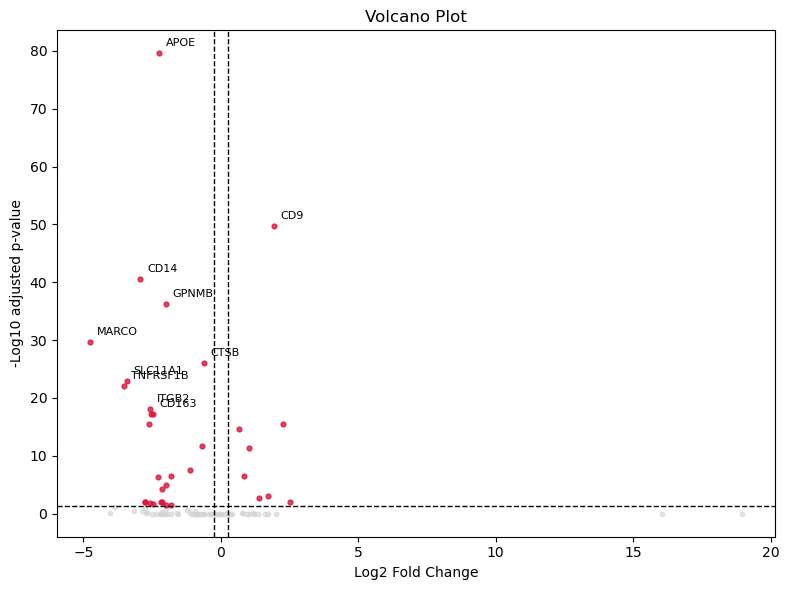

In [74]:
# Volcano plot of the significant genes
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# All genes
plt.scatter(
    df.loc[~df["significant"], "logfoldchanges"],
    df.loc[~df["significant"], "-log10_padj"],
    color="lightgrey",
    s=10,
    alpha=0.6
)

# Only significant
plt.scatter(
    df.loc[df["significant"], "logfoldchanges"],
    df.loc[df["significant"], "-log10_padj"],
    color="crimson",
    s=12,
    alpha=0.8
)

# threshold lines
plt.axhline(-np.log10(padj_thresh), linestyle="--", color="black", linewidth=1)
plt.axvline(logfc_thresh, linestyle="--", color="black", linewidth=1)
plt.axvline(-logfc_thresh, linestyle="--", color="black", linewidth=1)

# label top genes
top10 = df.sort_values("-log10_padj", ascending=False).head(10)

for _, row in top10.iterrows():
    plt.annotate(
        row["names"],
        (row["logfoldchanges"], row["-log10_padj"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 adjusted p-value")
plt.title("Volcano Plot")
plt.tight_layout()
plt.show()

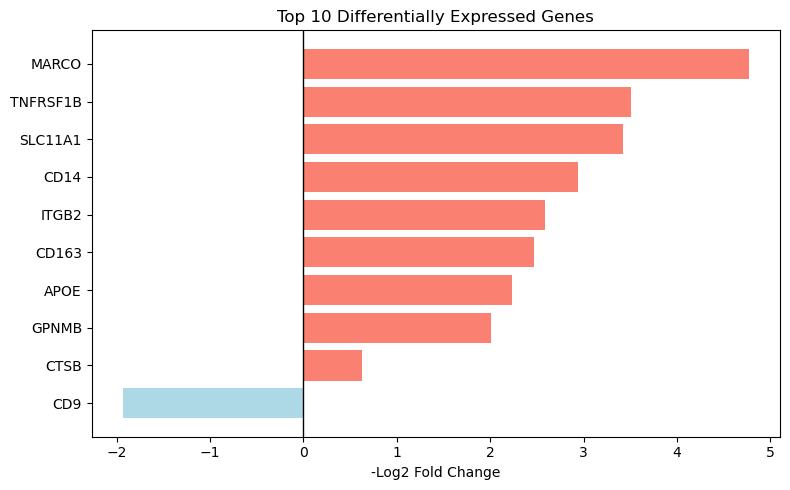

In [77]:
# Sort for barplot
top10 = top10.sort_values("logfoldchanges", ascending=False)

plt.figure(figsize=(8, 5))

plt.barh(
    top10["names"], 
    -top10["logfoldchanges"],   # <- flipped sign
    color=["salmon" if x > 0 else "lightblue" for x in -top10["logfoldchanges"]]
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("-Log2 Fold Change")
plt.title("Top 10 Differentially Expressed Genes")

plt.tight_layout()
plt.savefig("top10_DEG.jpeg", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
df.nsmallest(50, "logfoldchanges").sort_values("scores")

,names,scores,logfoldchanges,pvals,pvals_adj,significant,-log10_padj
90,APOE,-19.211395,-2.230633,2.971665e-82,2.704215e-80,True,79.567959
89,CD14,-13.717680,-2.936497,7.957142e-43,2.413667e-41,True,40.617323
88,GPNMB,-12.944139,-2.004613,2.535890e-38,5.769150e-37,True,36.238888
87,MARCO,-11.714910,-4.767850,1.069050e-31,1.945672e-30,True,29.710930
85,SLC11A1,-10.271039,-3.424511,9.517417e-25,1.237264e-23,True,22.907538
84,TNFRSF1B,-10.067440,-3.506129,7.695514e-24,8.753647e-23,True,22.057811
83,ITGB2,-9.107030,-2.582619,8.466831e-20,8.560907e-19,True,18.067480
82,CD163,-8.902856,-2.469102,5.442772e-19,4.952923e-18,True,17.305138
81,C1QA,-8.877097,-2.550565,6.862796e-19,5.677404e-18,True,17.245850
80,FCGR3A,-8.416410,-2.610921,3.881968e-17,2.943826e-16,True,15.531088
